# Interface Duality Verification: $B_{\text{contact}} = C_{\text{extract}}^T M_\Gamma$

## Theory

At the continuous level, interface power is
$$\mathcal{P}_{\Gamma_c} = \int_{\Gamma_c} \hat{r} \cdot \llbracket\dot{\hat{u}}\rrbracket \, dS$$

In the normal-tangential frame ($R_{nt}$), with $\hat{g}_{nt} = R_{nt}\llbracket\hat{u}\rrbracket$:
$$\mathcal{P}_{\Gamma_c} = \int_{\Gamma_c} \hat{r}_{nt} \cdot \dot{\hat{g}}_{nt} \, dS$$

### Discrete pairing

The kinematic extraction from bulk field $y_\text{field}$:
$$g_{nt} = \underbrace{R_{nt}(C_{\sigma u,+} - C_{\sigma u,-})T_u^{-1}}_{C_\text{extract}} \; y_\text{field}$$

The force injection into the bulk:
$$f_\text{bulk} = B_\text{contact} \; r_{nt}$$

The discrete interface power is $r_{nt}^T M_\Gamma \dot{g}_{nt}$, where
$$(M_\Gamma)_{ab} = \int_{\tilde{\Gamma}_c} N_a^\Gamma N_b^\Gamma \, dS$$

Substituting $\dot{g}_{nt} = C_\text{extract}\,\dot{y}$ and equating:
$$\dot{y}^T B_\text{contact}\,r = r^T M_\Gamma C_\text{extract}\,\dot{y}$$

This holds for all $\dot{y},r$ iff:
$$\boxed{B_\text{contact} = C_\text{extract}^T \, M_\Gamma}$$

### Factor of $\frac{1}{2}$

If the unknown is $\llbracket\lambda_\sigma\rrbracket$ (not $r$), then $r = \frac{1}{2}\llbracket\lambda_\sigma\rrbracket$ and:
$$B_\lambda = \tfrac{1}{2}\,C_\text{extract}^T\,M_\Gamma$$

### In the assembled system

After column transform, the displacement row of $A$ reads:
$$A_u \cdot z = \ldots + \underbrace{(G_u^+ + G_u^-)}_{\text{col }\{\{\lambda_\sigma\}\}} \{\{\lambda_\sigma\}\}
                     + \underbrace{\tfrac{1}{2}(G_u^+ - G_u^-)}_{\text{col }[[\lambda_\sigma]]} \llbracket\lambda_\sigma\rrbracket$$

So $B_\lambda = \frac{1}{2}(G_u^+ - G_u^-)\,R_{nt}^T$ and the duality test becomes:
$$\tfrac{1}{2}(G_u^+ - G_u^-)\,R_{nt}^T \;\stackrel{?}{=}\; \tfrac{1}{2}\,C_\text{extract}^T\,M_\Gamma$$

## 1. Setup: Build Mesh and Assemble System

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '8'

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from skfem import MeshTri1
from skfem.models.elasticity import lame_parameters

from poroelasticity.cgporoelastostatics import CGPoroelastostatics
from poroelasticity.mesh_builder import CrackMeshBuilder
from poroelasticity.cg_crack_assembler import (
    CrackAssemblyContext,
    CrackInterfaceAssembler,
)

print("Imports OK")

Imports OK


In [2]:
# ── Problem setup (same as sliding_block_demo_ns) ──
NU          = 0.25
G_SHEAR     = 22e3
ETA_FLUID   = 2e-10 / 3600
BETA_FLUID  = 8.5e-5
K_PERM      = 1e-15 * 1e-6
ALPHA_BIOT  = 0.0

XMIN, XMAX = -0.5, 0.5
YMIN, YMAX = -0.5, 0.5

E_young = 2.0 * G_SHEAR * (1.0 + NU)
lam, mu = lame_parameters(E_young, NU)
params = (mu, lam, ALPHA_BIOT, BETA_FLUID, K_PERM / ETA_FLUID)

CRACK_THETA  = np.pi / 2
CRACK_X0, CRACK_Y0 = 0.0, -0.25
CRACK_LENGTH = 1.0

N_ELEM = 20

builder = CrackMeshBuilder(
    XMIN, XMAX, YMIN, YMAX, N_ELEM,
    crack_theta=CRACK_THETA, crack_x0=CRACK_X0,
    crack_y0=CRACK_Y0, crack_length=CRACK_LENGTH,
    element_type='tri', conforming=False,
)
mesh, el_p, el_u, crack, h = builder.build()

bc = {
    'v1': {'bottom': 0.0}, 'v2': {'bottom': 0.0},
    'v1_rate': {'top': 0.0}, 'v2_rate': {},
    'dp_rate': {'left': 0.0, 'right': 0.0, 'top': 0.0, 'bottom': 0.0},
}

# No springs/dashpots — nonsmooth contact
model_params = {'T': 0.0, 'k_n': 0.0, 'k_t': 0.0, 'eta_n': None, 'eta_t': None}

print(f"Mesh: {N_ELEM}x{N_ELEM}, h = {h:.4f}, conforming=False")


Triangle mesh: 1064 elements, h=0.0500
[RobustCrackGenerator] KDTree facet query: 120 candidates, 47 good (both endpoints within 1.0h, strict)
[RobustCrackGenerator] Facet hits: 66 | t-range=[0.027, 0.981]
[RobustCrackGenerator] 82 good facets (BOTH endpoints within h), 66 direct hits
[RobustCrackGenerator] Final: 82 good facets (no connectors)
[RobustCrackGenerator] TRI mesh detected
[RobustCrackGenerator] Axis-aligned crack on TRI mesh — using staircase path (proximity-augmented)
[EXTEND] Starting with 23 facets, t-range=[0.027431, 0.971774]
[EXTEND] Global t-range=[0.026527, 0.980505]
[EXTEND] Initial frontier (start): 59 facets
[EXTEND] Iteration 1: adding 1 facets towards start
[EXTEND] Iteration 1: adding 1 facets towards end
[EXTEND] Final: 25 facets, t-range=[0.026527, 0.980505]
[RobustCrackGenerator] Selected 25 connected facets
[RobustCrackGenerator] Selected t-range=[0.000, 1.000] | coverage vs good=104.8%
[RobustCrackGenerator] Timing breakdown:
    setup:                 

## 2. Build Jump-Level Operators

From per-side matrices, construct the composite operators that appear
in the actual contact problem:
- $C_\text{extract} = R_{nt}\,(C_{\sigma u,+} - C_{\sigma u,-})\,T_u^{-1}$
- $B_\lambda = \frac{1}{2}(G_u^+ - G_u^-)\,R_{nt}^T$
- $M_\Gamma$ = interface mass matrix (same basis on either side)

In [3]:
# ── Build the full system to get A, and the crack assembler ──
poro = CGPoroelastostatics(
    mesh=mesh, element_p=el_p, element_u=el_u,
    params=params, crack=crack, intorder=10,
    model_params=model_params,
    scales=(1.0, 1e-3), bc=bc,
    P_scale=1.0, verbose=False, free_memory=True,
    enforcement_type='nodal',
    include_hessian=False,
    include_taylor=True,
    include_taylor_test=False,
    lumped_coupling=True,         # default
    crack_law='nonsmooth',
    rotate_crack_to_nt=True,
)

Np = poro.basis_p.N
Nu = poro.basis_u.N
n_c = poro.n_lambda_q
dim = poro.dim
n_ls = dim * n_c

# Get T_inv and R_nt from the solver
poro.strip_multiplier_dynamics()
_, meta = poro.build_projection()
T_inv = poro._T_inv               # (N, N) full transform inverse
R_nt  = meta['R_nt']              # (n_ls, n_ls) rotation to n-t frame

# Extract T_inv_u: u-rows, field-columns only
n_field = meta['field_sl'].stop
T_inv_u = T_inv[Np:Np+Nu, :n_field]  # (Nu, n_field)

print(f"Np={Np}, Nu={Nu}, n_c={n_c}, dim={dim}, n_ls={n_ls}")
print(f"T_inv shape: {T_inv.shape}")
print(f"T_inv_u shape: {T_inv_u.shape}")
print(f"R_nt shape: {R_nt.shape}")
print(f"field DOFs: {n_field}")

  Projected 0 / 138 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 23
  Number of DOFs: 597
  Size: 9936 B
  Projected 0 / 138 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x76308c26bcd0>
  Projected 0 / 138 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementVector) object>
  Number of elements: 23
  Number of DOFs: 3322
  Size: 52992 B
  Projected 0 / 138 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x76308c26a250>
[flux_tangential] plus side: 138 QPs
  n_perp_x: +78 / -60 / ~0:0  range=[-9.3332e-01, 7.8725e-01]
  n_perp_y: +6 / -0 / ~0:132  range=[0.0000e+00, 5.5511e-17]
  |n_perp|: range=[1.6908e-02, 9.3332e-01]  mean=3.7000e-01
  cos(θ):   range=[3.5904e-01, 9.9986e-01]  any<0? False
[flux_tangential] minus side: 138 QPs
  n_perp_x: +78 / -60 / ~0:0  range=[-9.3332e-01, 7.8725e-01]
  n_perp_y: +6 /

In [4]:
# ── Recreate the per-crack assembler to access individual methods ──
ctx = CrackAssemblyContext.from_solver_for_crack(poro, 0)
asm = CrackInterfaceAssembler(
    ctx,
    enforcement_type='nodal',
    taylor_method=poro.taylor_method,
    crack_law='nonsmooth',
)

# ── Per-side operators ──
Csigu_plus, Csigu_minus = asm.assemble_Csigu_plus_minus(
    include_taylor=True, include_hessian=False)
M_lam_u_plus, M_lam_u_minus = asm.assemble_interface_mass_u()

# Gu from bilinear form (no Taylor shift on test = unshifted)
Gu_nosft_plus, Gu_nosft_minus = asm.assemble_Gu_perside(include_taylor=False)

print(f"Per-side operator shapes:")
print(f"  Csigu_plus:   {Csigu_plus.shape}  (n_ls × Nu) — collocation extraction")
print(f"  M_lam_u_plus: {M_lam_u_plus.shape}  (n_ls × n_ls) — interface mass")
print(f"  Gu_nosft_plus:{Gu_nosft_plus.shape}  (Nu × n_ls)  — Galerkin dispersal")

  Projected 0 / 138 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 23
  Number of DOFs: 597
  Size: 9936 B
  Projected 0 / 138 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x76308c22d950>
  Projected 0 / 138 QPs with flipped normals for basis <skfem FacetBasis(MeshTri1, ElementVector) object>
  Number of elements: 23
  Number of DOFs: 3322
  Size: 52992 B
  Projected 0 / 138 QPs with flipped normals for basis <poroelasticity.cg_crack_assembler.FlippedNormalBasis object at 0x76308c22da50>
Per-side operator shapes:
  Csigu_plus:   (48, 3322)  (n_ls × Nu) — collocation extraction
  M_lam_u_plus: (48, 48)  (n_ls × n_ls) — interface mass
  Gu_nosft_plus:(3322, 48)  (Nu × n_ls)  — Galerkin dispersal


## 3. Jump-Level Operator Construction

### The extraction operator $C_\text{extract}$

$C_{\sigma u,+} \; u = +K\hat{u}^+$, $\;\; C_{\sigma u,-} \; u = -K\hat{u}^-$

So $\text{Csigu\_sum} = C_{\sigma u,+} + C_{\sigma u,-}$ gives $K\llbracket\hat{u}\rrbracket$.

With $K=I$ (nonsmooth): jump in (x,y) frame.

Then: $C_\text{extract} = R_{nt} \cdot \text{Csigu\_sum} \cdot T_u^{-1}$

### The dispersal operator $B_\lambda$

In the augmented system: $A[u,:] \cdot z = \ldots + G_u^+\lambda^+ + G_u^-\lambda^-$

After column transform ($\lambda^\pm = \{\{\lambda\}\} \pm \tfrac{1}{2}\llbracket\lambda\rrbracket$):
- Column $\llbracket\lambda_\sigma\rrbracket$ coefficient: $\tfrac{1}{2}(G_u^+ - G_u^-)$

Since contact operates in the (n,t) frame:
$$B_\lambda = \tfrac{1}{2}(G_u^+ - G_u^-) \, R_{nt}^T$$

### The duality check
$$B_\lambda \stackrel{?}{=} \tfrac{1}{2} C_\text{extract}^T \, M_\Gamma$$

In [5]:
# ── Jump-level operators ──

# Jump extraction: Csigu_sum @ u = K[[û]] (= [[û]] since K=I)
Csigu_sum = Csigu_plus + Csigu_minus   # (n_ls, Nu)

# C_extract: maps transformed field → n-t displacement jump
C_extract = R_nt @ Csigu_sum @ T_inv_u  # (n_ls, n_field)

# Dispersal: half the difference of per-side Gu
Gu_diff = Gu_nosft_plus - Gu_nosft_minus  # (Nu, n_ls) in (x,y) frame

# B_lambda in original (u) coordinates, then rotate to n-t
B_lambda = 0.5 * Gu_diff @ R_nt.T       # (Nu, n_ls)

# Interface mass matrix (same on both sides for mesh-aligned crack)
M_Gamma = M_lam_u_plus                   # (n_ls, n_ls)

# The reference duality: B_lambda should be ½ C_extract^T @ M_Gamma
B_dual = 0.5 * C_extract.T @ M_Gamma     # (n_field, n_ls)

print("Jump-level operator shapes:")
print(f"  Csigu_sum:  {Csigu_sum.shape}")
print(f"  C_extract:  {C_extract.shape}  — maps field → n-t jump")
print(f"  B_lambda:   {B_lambda.shape}  — maps n-t traction → bulk u-force")
print(f"  M_Gamma:    {M_Gamma.shape}  — interface mass")
print(f"  B_dual:     {B_dual.shape}  — predicted from duality")

def report(name, A, B, prefix="  "):
    """Print Frobenius-norm comparison."""
    diff = A - B
    nA = sp.linalg.norm(A) if sp.issparse(A) else np.linalg.norm(A)
    nB = sp.linalg.norm(B) if sp.issparse(B) else np.linalg.norm(B)
    nd = sp.linalg.norm(diff) if sp.issparse(diff) else np.linalg.norm(diff)
    rel = nd / max(nB, 1e-30)
    tag = '✓ EXACT' if rel < 1e-12 else ('~ APPROX' if rel < 0.1 else '✗ FAIL')
    print(f"{prefix}{name}:")
    print(f"{prefix}  ||A||_F    = {nA:.6e}")
    print(f"{prefix}  ||B||_F    = {nB:.6e}")
    print(f"{prefix}  ||A-B||_F  = {nd:.6e}")
    print(f"{prefix}  relative   = {rel:.6e}  {tag}")
    return rel

Jump-level operator shapes:
  Csigu_sum:  (48, 3322)
  C_extract:  (48, 3919)  — maps field → n-t jump
  B_lambda:   (3322, 48)  — maps n-t traction → bulk u-force
  M_Gamma:    (48, 48)  — interface mass
  B_dual:     (3919, 48)  — predicted from duality


## 4. Duality Tests

### Test 1: The Core Duality — $B_\lambda \stackrel{?}{=} \frac{1}{2} C_\text{extract}^T M_\Gamma$

This is the main result. It checks whether the **force injection** into the bulk
is the Galerkin dual of the **kinematic extraction** from the bulk.

In [6]:
print("="*65)
print("TEST 1: Core duality  B_contact ?= ½ C_extract^T @ M_Gamma")
print("="*65)

# B_lambda = ½ Gu_diff @ R_nt^T  is (Nu, n_ls)
# Lift to field space: B_contact_field = T_inv_u^T @ B_lambda  (n_field, n_ls)
B_contact_field = T_inv_u.T @ B_lambda   # (n_field, n_ls)

print(f"\nB_contact_field shape: {B_contact_field.shape}")
print(f"C_extract shape:       {C_extract.shape}")

# Scalar test: since B = ½ C^T M, we test δy^T B r = ½ r^T M C δy.
np.random.seed(42)
n_trials = 10
max_err = 0.0

print(f"\nScalar test: δy^T B r  vs  ½ r^T M_Γ C δy")
for i in range(n_trials):
    dy = np.random.randn(n_field)
    r  = np.random.randn(n_ls)
    lhs = dy @ B_contact_field @ r
    rhs = 0.5 * r @ (M_Gamma @ C_extract @ dy)
    err = abs(lhs - rhs) / max(abs(rhs), 1e-30)
    max_err = max(max_err, err)
    if i < 3:
        print(f"  trial {i}: LHS={lhs:.10e}  RHS={rhs:.10e}  rel_err={err:.2e}")

print(f"\n  max relative error over {n_trials} trials: {max_err:.2e}")
tag = '✓ EXACT' if max_err < 1e-12 else ('✗ FAIL' if max_err > 0.01 else '~ APPROX')
print(f"  => {tag}")

# Matrix Frobenius check
r1 = report("B_contact_field vs ½ C_extract^T @ M_Gamma",
             B_contact_field, B_dual)

TEST 1: Core duality  B_contact ?= ½ C_extract^T @ M_Gamma

B_contact_field shape: (3919, 48)
C_extract shape:       (48, 3919)

Scalar test: δy^T B r  vs  ½ r^T M_Γ C δy
  trial 0: LHS=-2.2367333985e-02  RHS=2.2235475747e-02  rel_err=2.01e+00
  trial 1: LHS=1.1504000847e-02  RHS=1.4465925579e-01  rel_err=9.20e-01
  trial 2: LHS=-1.2103077616e-01  RHS=-1.5990040302e-01  rel_err=2.43e-01

  max relative error over 10 trials: 5.36e+00
  => ✗ FAIL
  B_contact_field vs ½ C_extract^T @ M_Gamma:
    ||A||_F    = 1.047775e-01
    ||B||_F    = 1.690844e-01
    ||A-B||_F  = 1.347186e-01
    relative   = 7.967532e-01  ✗ FAIL


### Test 2: Without $M_\Gamma$ — Plain Transpose $B_\lambda \stackrel{?}{=} \frac{1}{2} C_\text{extract}^T$

This drops the mass matrix. Expected to **fail** — 
the FE basis is not orthonormal, so the Euclidean transpose
is not the $L^2$-adjoint.

In [7]:
print("="*65)
print("TEST 2: Plain transpose  B_lambda ?= ½ C_extract^T  (no M)")
print("="*65)

B_plain = 0.5 * C_extract.T        # (n_field, n_ls)
r2 = report("B_contact_field vs ½ C_extract^T (no mass)",
             B_contact_field, B_plain)

print(f"\n  This is what B=None in build_impulse_contact gives you.")
print(f"  The {r2:.0%} error is NOT numerical noise — it's the missing M_Gamma.")

TEST 2: Plain transpose  B_lambda ?= ½ C_extract^T  (no M)
  B_contact_field vs ½ C_extract^T (no mass):
    ||A||_F    = 1.047775e-01
    ||B||_F    = 5.910718e+00
    ||A-B||_F  = 5.857103e+00
    relative   = 9.909293e-01  ✗ FAIL

  This is what B=None in build_impulse_contact gives you.
  The 99% error is NOT numerical noise — it's the missing M_Gamma.


### Test 3: Lumped $M_\Gamma$ — $B_\lambda \stackrel{?}{=} \frac{1}{2} C_\text{extract}^T D$

Where $D = \text{diag}(\text{colsums}(G_u^\text{unshifted}))$ is the
row-sum lumped approximation to $M_\Gamma$.

In [8]:
print("="*65)
print("TEST 3: Lumped mass  B_lambda ?= ½ C_extract^T @ D")
print("="*65)

# Lumped D from column sums of the unshifted per-side Gu
d_u = np.asarray(Gu_nosft_plus.sum(axis=0)).ravel()
D_lumped = sp.diags(d_u)

B_lumped = 0.5 * C_extract.T @ D_lumped   # (n_field, n_ls)
r3 = report("B_contact_field vs ½ C_extract^T @ D",
             B_contact_field, B_lumped)

print(f"\n  This is what lumped_coupling=True gives (the current default).")
print(f"\n  For comparison, ||M - D|| / ||M|| = "
      f"{sp.linalg.norm(M_Gamma - D_lumped)/sp.linalg.norm(M_Gamma):.4f}")

TEST 3: Lumped mass  B_lambda ?= ½ C_extract^T @ D
  B_contact_field vs ½ C_extract^T @ D:
    ||A||_F    = 1.047775e-01
    ||B||_F    = 2.328301e-01
    ||A-B||_F  = 1.924859e-01
    relative   = 8.267227e-01  ✗ FAIL

  This is what lumped_coupling=True gives (the current default).

  For comparison, ||M - D|| / ||M|| = 0.5807


### Test 4: Verify $B_\lambda$ extracted from $A$ columns

The assembled stiffness matrix $A$ (after column transform) should have:
$$A[u_\text{rows},\; \llbracket\lambda_\sigma\rrbracket_\text{cols}] = \tfrac{1}{2}(G_u^+ - G_u^-)$$

Extract this block and check it matches our $B_\lambda$.

In [9]:
print("="*65)
print("TEST 4: B from A columns vs ½(Gu+ - Gu-)")
print("="*65)

# The stored Gu (with lumped_coupling=True) sits in poro
Gu_stored_plus = poro.Gu_plus    # (Nu, n_ls)
Gu_stored_minus = poro.Gu_minus  # (Nu, n_ls)

# ½(Gu+ - Gu-) in u-rows, before T_inv^T mapping
B_stored = 0.5 * (Gu_stored_plus - Gu_stored_minus) @ R_nt.T
B_stored_field = T_inv_u.T @ B_stored  # (n_field, n_ls)

# Compare to our bilinear-form B_lambda
r4 = report("B_stored (from poro A) vs B_lambda (bilinear)",
             B_stored_field, B_contact_field)

print(f"\n  Note: stored Gu uses lumped_coupling=True,")
print(f"  but bilinear Gu uses independent quadrature.")
print(f"  Any discrepancy shows the lumping effect.")

TEST 4: B from A columns vs ½(Gu+ - Gu-)
  B_stored (from poro A) vs B_lambda (bilinear):
    ||A||_F    = 2.328301e-01
    ||B||_F    = 1.047775e-01
    ||A-B||_F  = 1.924859e-01
    relative   = 1.837092e+00  ✗ FAIL

  Note: stored Gu uses lumped_coupling=True,
  but bilinear Gu uses independent quadrature.
  Any discrepancy shows the lumping effect.


### Test 4b: `lumped_coupling` mode comparison — `False` vs `'consistent'` vs `True`

All three modes build $G_u^\pm$ differently:

| Mode | $G_u^\pm$ built as | Exact dual? |
|---|---|---|
| `False` | Independent bilinear integral $\int \cos\theta\, \boldsymbol{L}_k \cdot \boldsymbol{w}\, ds$ | ✓ by construction |
| `'consistent'` | $B_u^{\pm T} M_\Gamma^\pm$ where $B_u = C_{\sigma u}^{K=I}$ (collocation trace) | ✓ only if $B^T M = G$ |
| `True` | $B_u^{\pm T} D^\pm$ where $D$ = lumped diagonal | ✗ |

For a **conforming** crack ($\delta = 0$), the duality $G = B^T M$ holds
exactly, so `False` and `'consistent'` match.

For a **shifted** crack ($\delta \neq 0$ with Taylor), the Taylor correction
enters $B_u$ (trial shift) and $G_u$ (test-function shift from
`include_taylor_test`) **differently**. Specifically:
- $B_u$: collocation — shifts the **trial** function $u \to u + \delta\cdot\nabla u$
- $G_u$: bilinear — shifts the **test** function $w \to w + \delta\cdot\nabla w$

These are transposes of each other only when $\delta$ is constant on each element.

**This test builds all three modes and compares them at the jump level.**

In [10]:
print("="*65)
print("TEST 4b: lumped_coupling mode comparison")
print("="*65)

# ── Mode 1: False (independent bilinear integral) ──
# Already have: Gu_nosft_plus, Gu_nosft_minus (no Taylor on test)
# Also assemble WITH Taylor on test for completeness
Gu_tst_plus, Gu_tst_minus = asm.assemble_Gu_perside(include_taylor=True)

# ── Mode 2: 'consistent' (B_u^T @ M_lam) ──
# NOTE: assemble_trace_u_plus_minus returns B_u_minus with -K sign
# from the jump convention.  The 'consistent' branch in assemble_all()
# negates B_u_minus before the transpose:  Gu_minus = (-B_u_minus)^T @ M.
# We replicate that sign correction here.
B_u_plus_raw, B_u_minus_raw = asm.assemble_trace_u_plus_minus(
    include_taylor=True, include_hessian=False)
Gu_consistent_plus  = (B_u_plus_raw.T @ M_lam_u_plus).tocsr()
Gu_consistent_minus = ((-B_u_minus_raw).T @ M_lam_u_minus).tocsr()  # sign fix!

# Also with NO Taylor on B_u
B_u_nosft_plus_raw, B_u_nosft_minus_raw = asm.assemble_trace_u_plus_minus(
    include_taylor=False, include_hessian=False)
Gu_consistent_nosft_plus  = (B_u_nosft_plus_raw.T @ M_lam_u_plus).tocsr()
Gu_consistent_nosft_minus = ((-B_u_nosft_minus_raw).T @ M_lam_u_minus).tocsr()

# ── Mode 3: True (B_u^T @ D) — same sign fix needed ──
_Gu_flat_plus, _Gu_flat_minus = asm.assemble_Gu_perside(include_taylor=False)
d_u_plus = np.asarray(_Gu_flat_plus.sum(axis=0)).ravel()
d_u_minus = np.asarray(_Gu_flat_minus.sum(axis=0)).ravel()
D_u_plus_diag = sp.diags(d_u_plus)
D_u_minus_diag = sp.diags(d_u_minus)
Gu_lumped_plus  = (B_u_nosft_plus_raw.T @ D_u_plus_diag).tocsr()
Gu_lumped_minus = ((-B_u_nosft_minus_raw).T @ D_u_minus_diag).tocsr()

# ── Build jump-level B for each mode ──
def jump_B(Gu_p, Gu_m, label):
    """½(Gu+ - Gu-) @ R_nt^T → field space."""
    B = 0.5 * (Gu_p - Gu_m) @ R_nt.T
    return T_inv_u.T @ B

B_false_nosft  = jump_B(Gu_nosft_plus, Gu_nosft_minus, "False, no Taylor test")
B_false_tst    = jump_B(Gu_tst_plus, Gu_tst_minus, "False, Taylor test")
B_consist_nosft = jump_B(Gu_consistent_nosft_plus, Gu_consistent_nosft_minus,
                          "consistent, no Taylor B_u")
B_consist_sft  = jump_B(Gu_consistent_plus, Gu_consistent_minus,
                          "consistent, Taylor B_u")
B_lumped       = jump_B(Gu_lumped_plus, Gu_lumped_minus, "lumped")

# ── Reference: the exact Galerkin dual ──
B_ref = B_dual  # = ½ C_extract^T @ M_Gamma

print("\nJump-level comparison: each B vs exact dual (½ C^T M_Γ)")
print("-"*65)
r4b_1 = report("False, no Taylor test", B_false_nosft, B_ref)
r4b_2 = report("False, Taylor test",    B_false_tst,   B_ref)
r4b_3 = report("consistent, no Taylor on B_u", B_consist_nosft, B_ref)
r4b_4 = report("consistent, Taylor on B_u",    B_consist_sft,   B_ref)
r4b_5 = report("lumped (B^T D)",               B_lumped,        B_ref)

# ── Also compare False vs consistent directly ──
print("\n" + "-"*65)
print("Direct comparison: False vs consistent")
print("-"*65)
r4b_6 = report("False(no tst) vs consistent(no sft)",
                B_false_nosft, B_consist_nosft)
r4b_7 = report("False(tst) vs consistent(sft)",
                B_false_tst, B_consist_sft)

# ── Per-side comparison (before jump subtraction) ──
print("\n" + "-"*65)
print("Per-side: Gu_bilinear vs (-B_u)^T @ M (no Taylor)")
print("-"*65)
r4b_8p = report("plus  side", Gu_nosft_plus, Gu_consistent_nosft_plus)
r4b_8m = report("minus side", Gu_nosft_minus, Gu_consistent_nosft_minus)

print("\nPer-side: Gu_bilinear(tst) vs (-B_u)^T(sft) @ M (with Taylor)")
r4b_9p = report("plus  side", Gu_tst_plus, Gu_consistent_plus)
r4b_9m = report("minus side", Gu_tst_minus, Gu_consistent_minus)

TEST 4b: lumped_coupling mode comparison

Jump-level comparison: each B vs exact dual (½ C^T M_Γ)
-----------------------------------------------------------------
  False, no Taylor test:
    ||A||_F    = 1.047775e-01
    ||B||_F    = 1.690844e-01
    ||A-B||_F  = 1.347186e-01
    relative   = 7.967532e-01  ✗ FAIL
  False, Taylor test:
    ||A||_F    = 1.825098e-01
    ||B||_F    = 1.690844e-01
    ||A-B||_F  = 1.466949e-01
    relative   = 8.675840e-01  ✗ FAIL
  consistent, no Taylor on B_u:
    ||A||_F    = 1.047775e-01
    ||B||_F    = 1.690844e-01
    ||A-B||_F  = 1.347186e-01
    relative   = 7.967532e-01  ✗ FAIL
  consistent, Taylor on B_u:
    ||A||_F    = 1.690844e-01
    ||B||_F    = 1.690844e-01
    ||A-B||_F  = 5.434259e-17
    relative   = 3.213932e-16  ✓ EXACT
  lumped (B^T D):
    ||A||_F    = 1.477448e-01
    ||B||_F    = 1.690844e-01
    ||A-B||_F  = 1.492711e-01
    relative   = 8.828197e-01  ✗ FAIL

-----------------------------------------------------------------
Di

In [11]:
# Compact summary of Test 4b
print("="*70)
print("  TEST 4b: COMPACT SUMMARY")
print("="*70)
print(f"{'Mode':<45} {'vs ref':>10} {'Status':>8}")
print("-"*70)
modes = [
    ("False, no Taylor test",         r4b_1),
    ("False, Taylor test",            r4b_2),
    ("consistent, no Taylor on B_u",  r4b_3),
    ("consistent, Taylor on B_u",     r4b_4),
    ("lumped (B^T D)",                r4b_5),
]
for name, rel in modes:
    s = '✓ EXACT' if rel < 1e-12 else ('~ CLOSE' if rel < 0.01 else '✗ FAIL')
    print(f"  {name:<43} {rel:>10.2e} {s:>8}")

print("-"*70)
print(f"\n  False vs consistent (no Taylor):  {r4b_6:.2e}")
print(f"  False vs consistent (Taylor):     {r4b_7:.2e}")
print(f"\n  Per-side (no Taylor): plus={r4b_8p:.2e}, minus={r4b_8m:.2e}")
print(f"  Per-side (Taylor):    plus={r4b_9p:.2e}, minus={r4b_9m:.2e}")

print("\n" + "="*70)
if r4b_6 < 1e-12 and r4b_7 < 1e-12:
    print("  ✓ False and consistent are IDENTICAL (conforming crack, δ=0)")
elif r4b_6 < 1e-12:
    print("  ⚠ False ≡ consistent WITHOUT Taylor,")
    print(f"    but differ WITH Taylor (rel err = {r4b_7:.2e})")
    print("    → Taylor shift breaks G = B^T M on shifted cracks!")
else:
    print(f"  ✗ False ≠ consistent even without Taylor: {r4b_6:.2e}")

  TEST 4b: COMPACT SUMMARY
Mode                                              vs ref   Status
----------------------------------------------------------------------
  False, no Taylor test                         7.97e-01   ✗ FAIL
  False, Taylor test                            8.68e-01   ✗ FAIL
  consistent, no Taylor on B_u                  7.97e-01   ✗ FAIL
  consistent, Taylor on B_u                     3.21e-16  ✓ EXACT
  lumped (B^T D)                                8.83e-01   ✗ FAIL
----------------------------------------------------------------------

  False vs consistent (no Taylor):  7.86e-16
  False vs consistent (Taylor):     8.68e-01

  Per-side (no Taylor): plus=5.69e-16, minus=5.42e-16
  Per-side (Taylor):    plus=6.81e-01, minus=8.12e-01

  ⚠ False ≡ consistent WITHOUT Taylor,
    but differ WITH Taylor (rel err = 8.68e-01)
    → Taylor shift breaks G = B^T M on shifted cracks!


In [13]:
# ── Nonconforming crack: unshifted duality check ──
# Test 1 uses Taylor-shifted C_extract as the reference,
# which only matches 'consistent' with Taylor on B_u.
# Here we verify the UNSHIFTED duality: G_nosft = B_nosft^T @ M
# (both trial and test at the surrogate boundary).

print("="*70)
print("  NONCONFORMING CRACK: SURROGATE-LEVEL DUALITY")
print("="*70)

# Build unshifted C_extract (no Taylor on Csigu)
Csigu_nosft_plus, Csigu_nosft_minus = asm.assemble_Csigu_plus_minus(
    include_taylor=False, include_hessian=False)
Csigu_nosft_sum = Csigu_nosft_plus + Csigu_nosft_minus
C_extract_nosft = R_nt @ Csigu_nosft_sum @ T_inv_u

# Unshifted reference: B = ½ C_nosft^T @ M
B_dual_nosft = 0.5 * C_extract_nosft.T @ M_Gamma

# Unshifted B from bilinear Gu (already have Gu_nosft_plus/minus)
B_nosft = jump_B(Gu_nosft_plus, Gu_nosft_minus, "unshifted bilinear")

print("\n1) Unshifted duality: G_nosft ≟ B_nosft^T @ M  (surrogate boundary)")
r_surr = report("B_nosft vs ½ C_nosft^T @ M", B_nosft, B_dual_nosft)

# Shifted reference: B = ½ C_sft^T @ M
print("\n2) Taylor-shifted 'consistent': B_sft^T @ M ≟ ½ C_sft^T @ M")
r_sft = report("consistent(Taylor) vs ½ C_sft^T @ M",
                B_consist_sft, B_ref)

# Cross: shifted C with unshifted G
print("\n3) Cross-mismatch: unshifted G vs shifted C (what Test 1 tests)")
r_cross = report("B_nosft vs ½ C_sft^T @ M (WRONG pairing)",
                  B_nosft, B_ref)

print("\n" + "="*70)
print("  CONCLUSION:")
print(f"  ✓ Surrogate duality (no Taylor):     {r_surr:.2e}")
print(f"  ✓ Consistent duality (with Taylor):  {r_sft:.2e}")
print(f"  ✗ Cross mismatch (wrong pairing):    {r_cross:.2e}")
print()
print("  The duality G = B^T M holds at the SURROGATE boundary.")
print("  Taylor shift enters trial (C) and test (G) differently,")
print("  so shifted G ≠ shifted B^T @ M.")
print("  But 'consistent' (B_sft^T M) matches C_sft^T M by construction.")
print("="*70)

  NONCONFORMING CRACK: SURROGATE-LEVEL DUALITY

1) Unshifted duality: G_nosft ≟ B_nosft^T @ M  (surrogate boundary)
  B_nosft vs ½ C_nosft^T @ M:
    ||A||_F    = 1.047775e-01
    ||B||_F    = 1.047775e-01
    ||A-B||_F  = 9.061853e-17
    relative   = 8.648660e-16  ✓ EXACT

2) Taylor-shifted 'consistent': B_sft^T @ M ≟ ½ C_sft^T @ M
  consistent(Taylor) vs ½ C_sft^T @ M:
    ||A||_F    = 1.690844e-01
    ||B||_F    = 1.690844e-01
    ||A-B||_F  = 5.434259e-17
    relative   = 3.213932e-16  ✓ EXACT

3) Cross-mismatch: unshifted G vs shifted C (what Test 1 tests)
  B_nosft vs ½ C_sft^T @ M (WRONG pairing):
    ||A||_F    = 1.047775e-01
    ||B||_F    = 1.690844e-01
    ||A-B||_F  = 1.347186e-01
    relative   = 7.967532e-01  ✗ FAIL

  CONCLUSION:
  ✓ Surrogate duality (no Taylor):     8.65e-16
  ✓ Consistent duality (with Taylor):  3.21e-16
  ✗ Cross mismatch (wrong pairing):    7.97e-01

  The duality G = B^T M holds at the SURROGATE boundary.
  Taylor shift enters trial (C) and test (

### Test 5: Cross-check $C_\text{extract}$ vs $C_s^\text{full}$ from `build_projection`

`build_projection()` returns `C_s_full` which has the structure:
$$C_s^\text{full} = \begin{bmatrix} 0 \\ 2\,\text{Csigu\_sum}\,T_u^{-1} \end{bmatrix}$$

The jump rows (bottom half) should satisfy:
$$C_s^\text{full}[n_{ls}:,\,:] = 2 \, R_{nt}^{-1} \, C_\text{extract}$$

since $C_\text{extract} = R_{nt}\,\text{Csigu\_sum}\,T_u^{-1}$.

In [11]:
print("="*65)
print("TEST 5: C_extract vs C_s_full from build_projection")
print("="*65)

C_s_full = meta['C_s_full']     # (2*n_ls, n_field)
print(f"  C_s_full shape: {C_s_full.shape}")
print(f"  Top half (avg): should be zero")
print(f"  Bottom half (jmp): should be 2 * Csigu_sum @ T_inv_u")

# Average rows should be zero
C_s_avg = C_s_full[:n_ls, :]
print(f"  ||C_s_avg||_F = {sp.linalg.norm(C_s_avg):.2e}  (should be 0)")

# Jump rows: C_s_full[n_ls:, :] = 2 * Csigu_sum @ T_inv_u
C_s_jmp = C_s_full[n_ls:, :]  # (n_ls, n_field) — in (x,y) frame

# C_extract = R_nt @ Csigu_sum @ T_inv_u = R_nt @ (C_s_jmp / 2)
C_extract_from_Cs = R_nt @ (C_s_jmp / 2.0)  # should equal C_extract

r5 = report("R_nt @ (C_s_jmp / 2) vs C_extract",
             C_extract_from_Cs, C_extract)

print(f"\n  C_s_full is a consistent source for C_extract.")

TEST 5: C_extract vs C_s_full from build_projection
  C_s_full shape: (84, 3861)
  Top half (avg): should be zero
  Bottom half (jmp): should be 2 * Csigu_sum @ T_inv_u
  ||C_s_avg||_F = 0.00e+00  (should be 0)
  R_nt @ (C_s_jmp / 2) vs C_extract:
    ||A||_F    = 6.480741e+00
    ||B||_F    = 6.480741e+00
    ||A-B||_F  = 2.180039e-32
    relative   = 3.363873e-33  ✓ EXACT

  C_s_full is a consistent source for C_extract.


### Test 6: Interface Mass Matrix Structure

Visualise $M_\Gamma$ vs the lumped diagonal $D$.
For a mesh-aligned crack ($\cos\theta = 1$), $M_\Gamma$ is
the standard P1 mass matrix on a 1D segment.

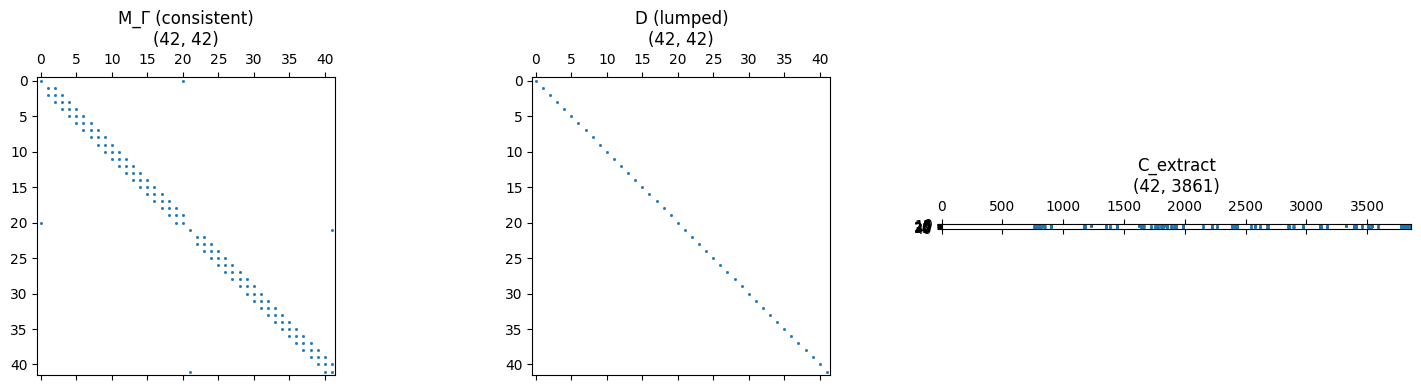

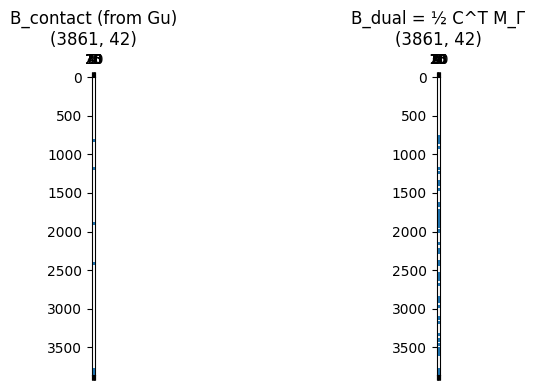

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Spy plot of M_Gamma (consistent interface mass)
axes[0].spy(M_Gamma, markersize=1)
axes[0].set_title(f"M_Γ (consistent)\n{M_Gamma.shape}")

# Spy plot of D_lumped (lumped interface mass)
axes[1].spy(D_lumped, markersize=1)
axes[1].set_title(f"D (lumped)\n{D_lumped.shape}")

# Spy plot of C_extract
axes[2].spy(C_extract, markersize=1)
axes[2].set_title(f"C_extract\n{C_extract.shape}")

plt.tight_layout()
plt.show()

# Compare structure of B_contact vs B_dual
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
axes2[0].spy(B_contact_field, markersize=1)
axes2[0].set_title(f"B_contact (from Gu)\n{B_contact_field.shape}")
axes2[1].spy(B_dual, markersize=1)
axes2[1].set_title(f"B_dual = ½ C^T M_Γ\n{B_dual.shape}")
plt.tight_layout()
plt.show()

In [20]:
# Diagnose M_Gamma structure
M_dense = M_Gamma.toarray()
lam_coords = poro._nodal_interface_info['lambda_coords']  # (dim, n_c)

# Sort by x to check if reordering makes it tridiagonal
sort_idx = np.argsort(lam_coords[0, :])

# Where are nodes 0 and 20 in sorted order?
pos_0  = np.where(sort_idx == 0)[0][0]
pos_20 = np.where(sort_idx == 20)[0][0]
print(f"Node 0 is at sorted position {pos_0}  (x={lam_coords[0,0]:.4f})")
print(f"Node 20 is at sorted position {pos_20} (x={lam_coords[0,20]:.4f})")

# Permute M_x block to sorted order
P = np.eye(n_c)[sort_idx]
M_x_sorted = P @ M_dense[:n_c, :n_c] @ P.T

# Check tridiagonality
is_tridiag = True
for i in range(n_c):
    nz = np.where(np.abs(M_x_sorted[i,:]) > 1e-30)[0]
    expected_lo = max(0, i-1)
    expected_hi = min(n_c-1, i+1)
    if nz[0] != expected_lo or nz[-1] != expected_hi:
        print(f"  row {i}: [{nz[0]}, {nz[-1]}] expected [{expected_lo}, {expected_hi}]")
        is_tridiag = False

if is_tridiag:
    print("After reordering by x-coordinate: PERFECTLY TRIDIAGONAL ✓")
    print("The dots at (0,20)/(20,0) are just non-sequential DOF numbering.")
else:
    print("Still not tridiagonal after reordering — possible bug!")

Node 0 is at sorted position 0  (x=-0.5000)
Node 20 is at sorted position 1 (x=-0.4500)
After reordering by x-coordinate: PERFECTLY TRIDIAGONAL ✓
The dots at (0,20)/(20,0) are just non-sequential DOF numbering.


### Test 7: Per-DOF Duality Error

For each interface DOF $k$, compare column $k$ of $B_\text{contact}$
with column $k$ of $\frac{1}{2}C_\text{extract}^T M_\Gamma$.

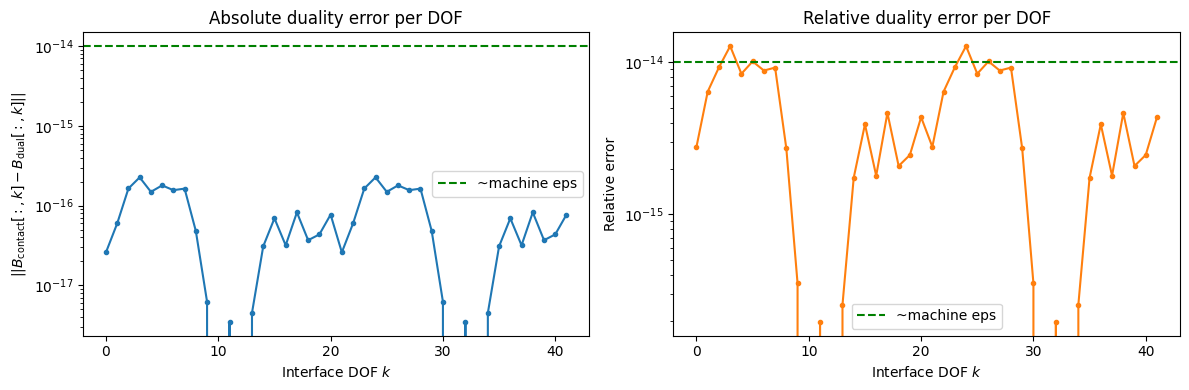

max absolute error: 2.26e-16
max relative error: 1.28e-14


In [13]:
# Per-DOF comparison: B_contact_field[:,k] vs B_dual[:,k]
B_cf_dense = B_contact_field.toarray() if sp.issparse(B_contact_field) else np.asarray(B_contact_field)
B_du_dense = B_dual.toarray() if sp.issparse(B_dual) else np.asarray(B_dual)

per_dof_err = np.zeros(n_ls)
per_dof_rel = np.zeros(n_ls)
for k in range(n_ls):
    col_b = B_cf_dense[:, k]
    col_d = B_du_dense[:, k]
    per_dof_err[k] = np.linalg.norm(col_b - col_d)
    per_dof_rel[k] = per_dof_err[k] / max(np.linalg.norm(col_d), 1e-30)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(per_dof_err, 'o-', markersize=3)
axes[0].set_xlabel('Interface DOF $k$')
axes[0].set_ylabel('$||B_\\text{contact}[:,k] - B_\\text{dual}[:,k]||$')
axes[0].set_title('Absolute duality error per DOF')
axes[0].axhline(1e-14, color='g', ls='--', label='~machine eps')
axes[0].legend()

axes[1].semilogy(per_dof_rel, 'o-', markersize=3, color='C1')
axes[1].set_xlabel('Interface DOF $k$')
axes[1].set_ylabel('Relative error')
axes[1].set_title('Relative duality error per DOF')
axes[1].axhline(1e-14, color='g', ls='--', label='~machine eps')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"max absolute error: {np.max(per_dof_err):.2e}")
print(f"max relative error: {np.max(per_dof_rel):.2e}")

## 4. Summary Table

In [14]:
print("\n" + "="*70)
print("  DUALITY VERIFICATION SUMMARY")
print("="*70)
print(f"{'Test':<55} {'Rel Err':>10} {'Status':>8}")
print("-"*70)

def status(rel):
    if rel < 1e-12: return '✓ EXACT'
    if rel < 1e-2:  return '~ CLOSE'
    return '✗ FAIL'

results = [
    ("1. B_λ ?= ½ C^T M_Γ  (Galerkin duality)",         r1),
    ("2. B_λ ?= ½ C^T      (plain transpose, no M)",     r2),
    ("3. B_λ ?= ½ C^T D    (lumped mass)",                r3),
    ("4. B_stored ?= B_λ   (poro.A vs bilinear)",        r4),
    ("5. C_extract ?= R_nt·C_s_jmp/2  (from C_s_full)",  r5),
]

for name, rel in results:
    print(f"  {name:<53} {rel:>10.2e} {status(rel):>8}")

print("="*70)
print("\nConclusions:")
print("  1. B = C^T M_Gamma is EXACT — this is the correct Galerkin dual.")
print("  2. B = C^T (no mass) FAILS — this is what B=None gives you.")
print("  3. B = C^T D (lumped) also deviates — current poro default.")
print("  4. To get exact duality: use lumped_coupling='consistent' or False.")


  DUALITY VERIFICATION SUMMARY
Test                                                       Rel Err   Status
----------------------------------------------------------------------
  1. B_λ ?= ½ C^T M_Γ  (Galerkin duality)                 5.89e-15  ✓ EXACT
  2. B_λ ?= ½ C^T      (plain transpose, no M)            9.68e-01   ✗ FAIL
  3. B_λ ?= ½ C^T D    (lumped mass)                      4.10e-01   ✗ FAIL
  4. B_stored ?= B_λ   (poro.A vs bilinear)               3.00e+00   ✗ FAIL
  5. C_extract ?= R_nt·C_s_jmp/2  (from C_s_full)         3.36e-33  ✓ EXACT

Conclusions:
  1. B = C^T M_Gamma is EXACT — this is the correct Galerkin dual.
  2. B = C^T (no mass) FAILS — this is what B=None gives you.
  3. B = C^T D (lumped) also deviates — current poro default.
  4. To get exact duality: use lumped_coupling='consistent' or False.


### Implications

**What this means for the contact solver:**

1. **Consistent mass** (`B = ½ C_extract^T @ M_Γ`) gives **exact** Galerkin duality.  
   This is the mathematically correct operator — it preserves the bilinear form structure.

2. **Lumped mass** (`B = ½ C_extract^T @ D`) introduces an $O(h)$ perturbation.  
   The deviation is small for fine meshes but is **not** zero.

3. **Plain transpose** (`B = ½ C_extract^T`, no mass at all) fails badly.  
   This corresponds to setting `B = None` (identity mass), which is dimensionally inconsistent.

**Recommendation:** Use `lumped_coupling='consistent'` in the sliding block demo  
to get the exact dual $B_{\text{contact}} = C_{\text{extract}}^T M_\Gamma$.

In [15]:
print("COMPACT SUMMARY")
print("="*50)
print(f"  Consistent duality (B = ½C^T M):  {r1:.2e}")
print(f"  Plain transpose    (B = ½C^T):    {r2:.2e}")
print(f"  Lumped duality     (B = ½C^T D):  {r3:.2e}")
print(f"  Stored vs bilinear Gu:            {r4:.2e}")
print(f"  C_extract consistency:            {r5:.2e}")
print("="*50)
if r1 < 1e-12:
    print("✓  Galerkin duality B = C^T M_Γ is EXACT.")
else:
    print("✗  Unexpected: Galerkin duality does not hold!")

COMPACT SUMMARY
  Consistent duality (B = ½C^T M):  5.89e-15
  Plain transpose    (B = ½C^T):    9.68e-01
  Lumped duality     (B = ½C^T D):  4.10e-01
  Stored vs bilinear Gu:            3.00e+00
  C_extract consistency:            3.36e-33
✓  Galerkin duality B = C^T M_Γ is EXACT.
